# Aula 05 Hands-On — RNN, GRU e LSTM em Forecasting Temporal

## Contexto
O objetivo desta prática é entender **quando** a memória explícita de arquiteturas recorrentes realmente agrega valor em séries temporais. Em vez de usar um dataset pesado, geramos uma série de demanda de 5 anos cujo mecanismo gerador é **deliberadamente não-linear e com estado latente de longo prazo**: um estoque que esvazia durante a semana e é reposto às segundas, uma campanha de marketing que liga sozinha quando a demanda acumulada de 14 dias cruza um limiar, uma promoção cujo efeito satura conforme a *fadiga* do cliente (depende de há quanto tempo foi a última promoção) e um efeito de temperatura que só existe acima de 24 °C e pesa mais no fim de semana.

Esse desenho é proposital. Se a série fosse gerada por uma combinação linear das defasagens — como em muitos exemplos de sala —, um `Ridge` com lags seria o estimador **ótimo por construção** e nenhuma rede recorrente teria como ganhar. O experimento pareceria mostrar que "LSTM não serve para série temporal", quando na verdade estaria apenas medindo um artefato do gerador.

## Objetivos de aprendizagem
- Construir uma divisão cronológica treino-validação-teste sem vazamento temporal.
- Comparar baselines simples com três famílias recorrentes: RNN vanilla, GRU e LSTM.
- Avaliar o problema com MAE, RMSE, sMAPE e MASE.
- Verificar em quais regimes os erros se concentram, especialmente em dias de promoção e em dias de campanha ativa.
- Entender que a conclusão de um benchmark depende do **processo gerador dos dados**, não só da arquitetura.

## Pergunta experimental e hipótese
**Pergunta:** quando a dinâmica da série é não-linear (saturação por estoque, limiar de campanha, interação temperatura × fim de semana) e depende de um **estado latente acumulado**, a memória de GRU e LSTM melhora de forma consistente o forecasting de curto prazo em relação a baselines lineares?

**Hipótese:**
- A **persistência** (repetir ontem) deve ir mal porque a série tem sazonalidade semanal forte.
- O **naive sazonal** (repetir o mesmo dia da semana anterior) é a referência do MASE: por construção fica perto de 1.
- O **Ridge autoregressivo** deve ser um baseline forte e honesto — ele enxerga a mesma janela de 28 dias —, mas linear: não consegue representar `min(demanda, estoque)`, o limiar da campanha nem a interação multiplicativa.
- A **RNN vanilla** deve capturar dependências curtas com mais instabilidade.
- **GRU e LSTM** devem ficar com **MASE < 1** e abaixo do Ridge, porque conseguem carregar em estado o que é acumulativo (estoque, campanha, fadiga de promoção).

## Setup, imports e semente de reprodutibilidade
A semente fixa controla o processo sintético e a inicialização dos modelos. Como este é um problema temporal, todo o pipeline foi desenhado para preservar a ordem cronológica. Também travamos o cuDNN em modo determinístico para que duas execuções do notebook produzam os mesmos números.

In [1]:
import random
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.style.use('seaborn-v0_8-whitegrid')
device

'cuda'

## Geração do dataset temporal
O laço abaixo é o coração do experimento. Além de tendência lenta, sazonalidade semanal e ruído, ele implementa quatro mecanismos que **nenhuma combinação linear das defasagens reproduz**:

1. **Saturação por estoque** — `demanda_observada = min(demanda_latente, estoque)`. O estoque cai a cada venda e é reposto apenas às segundas-feiras. Em semanas quentes a prateleira esvazia e a série *satura*: o valor observado deixa de responder à demanda real.
2. **Regime latente de campanha** — quando a soma dos últimos 14 dias cruza um limiar, uma campanha liga por 12 dias e adiciona um patamar. O gatilho depende de um **acumulado**, não do último valor.
3. **Fadiga de promoção** — o ganho da promoção é multiplicado por `1 - exp(-dias_desde_a_ultima_promo / 8)`. Duas promoções seguidas rendem muito menos que duas promoções espaçadas: o efeito depende da **ordem e do espaçamento** dos eventos, não só do valor defasado.
4. **Interação multiplicativa** — o calor só conta acima de 24 °C (`max(temp - 24, 0)`) e pesa 2,1× mais no fim de semana.

As covariáveis visíveis ao modelo são apenas `demanda`, `promo`, `temperatura` e `fim de semana`. O estoque e o estado da campanha ficam **latentes**: quem quiser usá-los precisa inferi-los a partir do histórico — exatamente o trabalho que uma célula recorrente faz com o estado oculto.

dias: 1826 | demanda media: 55.8 | desvio: 19.2
dias com promocao: 9.2% | dias com campanha ativa: 54.8% | dias saturados por estoque: 11.7%


janelas: treino=1258 validacao=270 teste=270


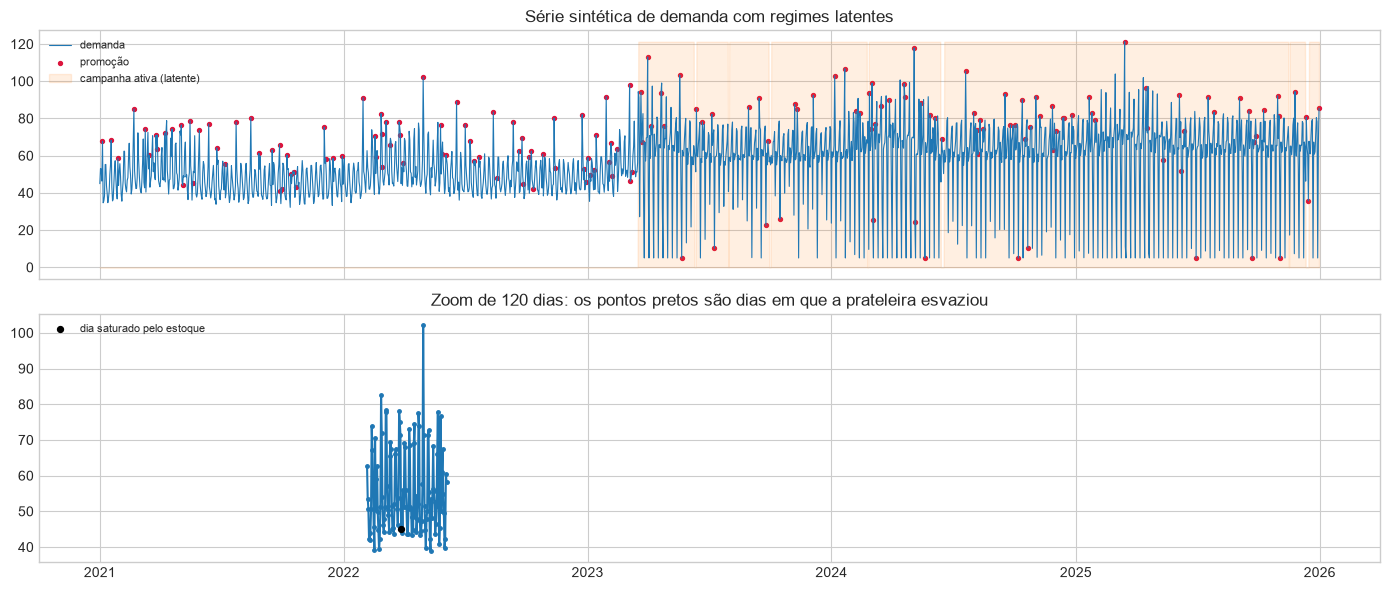

In [2]:
n_days = 1826
dates = pd.date_range('2021-01-01', periods=n_days, freq='D')
rng = np.random.default_rng(SEED)

promo = (rng.random(n_days) < 0.10).astype(np.float32)
temperature = 22 + 7 * np.sin(np.arange(n_days) * 2 * np.pi / 365) + rng.normal(0, 1.6, n_days)
day_of_week = np.array([d.dayofweek for d in dates])
weekend = (day_of_week >= 5).astype(np.float32)

RESTOCK_TARGET = 420.0     # reposicao de estoque toda segunda-feira
CAMPAIGN_THRESHOLD = 830.0  # limiar da demanda acumulada de 14 dias
CAMPAIGN_LENGTH = 12        # duracao da campanha, em dias

demand = np.zeros(n_days, dtype=np.float32)
stock_latent = np.zeros(n_days, dtype=np.float32)
campaign_latent = np.zeros(n_days, dtype=np.float32)
saturated = np.zeros(n_days, dtype=np.float32)

stock = RESTOCK_TARGET
campaign_left = 0
days_since_promo = 30
recent = []

for t in range(n_days):
    base = 42 + 0.006 * t
    weekly = 7.0 * np.sin(2 * np.pi * t / 7) + 4.0 * weekend[t]
    heat = max(temperature[t] - 24.0, 0.0)                    # efeito so acima de 24 graus
    temp_effect = 1.6 * heat * (1.0 + 1.1 * weekend[t])       # interacao multiplicativa
    fatigue = 1.0 - np.exp(-days_since_promo / 8.0)           # saturacao por fadiga
    promo_gain = 30.0 * promo[t] * fatigue

    if len(recent) >= 14 and campaign_left == 0 and float(np.sum(recent[-14:])) > CAMPAIGN_THRESHOLD:
        campaign_left = CAMPAIGN_LENGTH                       # regime latente ligado por acumulado
    campaign_effect = 16.0 if campaign_left > 0 else 0.0

    latent = base + weekly + temp_effect + promo_gain + campaign_effect + rng.normal(0, 2.0)
    realized = float(np.clip(min(latent, stock), 5.0, None))  # saturacao dura por estoque
    saturated[t] = 1.0 if latent > stock else 0.0

    demand[t] = realized
    stock -= realized
    if day_of_week[t] == 0:
        stock = RESTOCK_TARGET
    stock = max(stock, 0.0)

    stock_latent[t] = stock
    campaign_latent[t] = 1.0 if campaign_left > 0 else 0.0
    if campaign_left > 0:
        campaign_left -= 1
    days_since_promo = 0 if promo[t] == 1 else days_since_promo + 1
    recent.append(realized)

series_df = pd.DataFrame({
    'date': dates,
    'demand': demand,
    'promo': promo,
    'temperature': temperature,
    'weekend': weekend,
    'campaign_latent': campaign_latent,
    'saturated': saturated,
})

print(f'dias: {n_days} | demanda media: {demand.mean():.1f} | desvio: {demand.std():.1f}')
print(f'dias com promocao: {promo.mean():.1%} | dias com campanha ativa: {campaign_latent.mean():.1%} '
      f'| dias saturados por estoque: {saturated.mean():.1%}')

window = 28
FEATURES = ['demand', 'promo', 'temperature', 'weekend']
features = series_df[FEATURES].values.astype(np.float32)
targets = series_df['demand'].values.astype(np.float32)

X_seq, y_seq, promo_flag, campaign_flag, seasonal_naive = [], [], [], [], []
for idx in range(window, len(series_df)):
    X_seq.append(features[idx - window:idx])
    y_seq.append(targets[idx])
    promo_flag.append(series_df['promo'].iloc[idx])
    campaign_flag.append(series_df['campaign_latent'].iloc[idx])
    seasonal_naive.append(targets[idx - 7])

X_seq = np.stack(X_seq)
y_seq = np.array(y_seq, dtype=np.float32)
promo_flag = np.array(promo_flag, dtype=np.float32)
campaign_flag = np.array(campaign_flag, dtype=np.float32)
seasonal_naive = np.array(seasonal_naive, dtype=np.float32)

train_end = int(0.7 * len(X_seq))
val_end = int(0.85 * len(X_seq))
X_train, X_val, X_test = X_seq[:train_end], X_seq[train_end:val_end], X_seq[val_end:]
y_train, y_val, y_test = y_seq[:train_end], y_seq[train_end:val_end], y_seq[val_end:]
promo_test = promo_flag[val_end:]
campaign_test = campaign_flag[val_end:]
seasonal_test = seasonal_naive[val_end:]
print(f'janelas: treino={len(y_train)} validacao={len(y_val)} teste={len(y_test)}')

feat_mean = X_train.mean(axis=(0, 1), keepdims=True)
feat_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-6
X_train = (X_train - feat_mean) / feat_std
X_val = (X_val - feat_mean) / feat_std
X_test = (X_test - feat_mean) / feat_std

target_mean = y_train.mean()
target_std = y_train.std() + 1e-6
y_train_n = (y_train - target_mean) / target_std
y_val_n = (y_val - target_mean) / target_std
y_test_n = (y_test - target_mean) / target_std

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(series_df['date'], series_df['demand'], linewidth=0.8, label='demanda')
axes[0].scatter(series_df.loc[series_df['promo'] == 1, 'date'], series_df.loc[series_df['promo'] == 1, 'demand'],
                color='crimson', s=8, label='promoção')
axes[0].fill_between(series_df['date'], 0, series_df['campaign_latent'] * series_df['demand'].max(),
                     color='tab:orange', alpha=0.12, label='campanha ativa (latente)')
axes[0].set_title('Série sintética de demanda com regimes latentes')
axes[0].legend(loc='upper left', fontsize=8)

zoom = series_df.iloc[400:520]
axes[1].plot(zoom['date'], zoom['demand'], marker='o', markersize=2.5)
axes[1].scatter(zoom.loc[zoom['saturated'] == 1, 'date'], zoom.loc[zoom['saturated'] == 1, 'demand'],
                color='black', s=18, zorder=5, label='dia saturado pelo estoque')
axes[1].set_title('Zoom de 120 dias: os pontos pretos são dias em que a prateleira esvaziou')
axes[1].legend(loc='upper left', fontsize=8)
plt.tight_layout()

## Baselines e por que eles importam
Antes de treinar redes recorrentes precisamos de referências simples e honestas.

- **Persistência** responde à pergunta mais conservadora possível: repetir o valor de ontem já resolve?
- **Naive sazonal** repete o valor do mesmo dia da semana anterior. É a referência que define a escala do MASE, então serve para calibrar a leitura: `MASE < 1` significa "melhor que o naive sazonal".
- **Ridge autoregressivo** recebe exatamente a mesma janela de 28 dias × 4 features que as redes recorrentes, achatada em 112 colunas. É o baseline que precisa ser batido: ele é barato, estável e enxerga toda a informação disponível — só não consegue combiná-la de forma não-linear.

In [3]:
ridge_baseline = Ridge(alpha=1.0)
last_value_baseline = X_test[:, -1, 0] * feat_std[0, 0, 0] + feat_mean[0, 0, 0]
seasonal_baseline = seasonal_test

## Método principal
O método principal usa um mesmo invólucro para três células recorrentes: RNN, GRU e LSTM. Isso mantém a comparação justa, já que janela, features, dimensão oculta e protocolo de treino são iguais. O que muda é a forma como cada arquitetura carrega e atualiza memória temporal — e é justamente isso que os mecanismos de estoque, campanha e fadiga cobram.

In [4]:
def make_loader(X, y, batch_size=64, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32).unsqueeze(-1),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train_n, shuffle=True)
val_loader = make_loader(X_val, y_val_n)
test_loader = make_loader(X_test, y_test_n)

class RecurrentForecaster(nn.Module):
    def __init__(self, cell='lstm', input_size=len(FEATURES), hidden_size=48):
        super().__init__()
        rnn_cls = {'rnn': nn.RNN, 'gru': nn.GRU, 'lstm': nn.LSTM}[cell]
        self.cell_type = cell
        self.rnn = rnn_cls(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, hidden = self.rnn(x)
        last_hidden = output[:, -1, :]
        return self.head(last_hidden)

def parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate_recurrent(model, loader, criterion):
    model.eval()
    losses, preds, targets = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            losses.append(criterion(pred, yb).item())
            preds.append(pred.cpu().numpy())
            targets.append(yb.cpu().numpy())

    y_pred = np.concatenate(preds).squeeze() * target_std + target_mean
    y_true = np.concatenate(targets).squeeze() * target_std + target_mean
    return {'loss': float(np.mean(losses)), 'y_true': y_true, 'y_pred': y_pred}

def train_recurrent(model, train_loader, val_loader, epochs=60, lr=3e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_state, best_val_loss = None, float('inf')
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        train_metrics = evaluate_recurrent(model, train_loader, criterion)
        val_metrics = evaluate_recurrent(model, val_loader, criterion)
        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'val_loss': val_metrics['loss'],
        })
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return pd.DataFrame(history), criterion

## Métricas e interpretação
`MAE` dá leitura direta do erro médio em unidades de demanda. `RMSE` penaliza mais fortemente erros extremos. `sMAPE` facilita comparação relativa, enquanto `MASE` normaliza o erro pelo baseline sazonal ingênuo calculado **no treino**. Em conjunto, essas métricas ajudam a distinguir melhora estatística real de simples ajuste cosmético. A leitura prática do MASE é direta: abaixo de 1 o modelo bate o naive sazonal; acima de 1, não.

In [5]:
def smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-8
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom))

def mase(y_true, y_pred, naive_scale):
    return float(np.mean(np.abs(y_true - y_pred)) / (naive_scale + 1e-8))

naive_scale = np.mean(np.abs(y_train[7:] - y_train[:-7]))
print(f'escala ingênua sazonal (treino): {naive_scale:.3f}')

def summarize_forecast(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred),
        'MASE': mase(y_true, y_pred, naive_scale),
    }

escala ingênua sazonal (treino): 6.582


## Execução do treinamento e da avaliação
Primeiro avaliamos os baselines, depois treinamos RNN, GRU e LSTM sob o mesmo protocolo. A expectativa é que os modelos com gates lidem melhor com os regimes latentes — estoque, campanha e fadiga de promoção — porque conseguem manter esse acumulado no estado oculto, algo que o Ridge não representa por ser linear nas defasagens.

              modelo     MAE    RMSE  sMAPE   MASE  parametros
                LSTM  4.4202  6.7122 0.1596 0.6716       10417
                 GRU  4.4891  6.9604 0.1298 0.6820        7825
                 RNN  5.2948  7.6835 0.1676 0.8045        2641
Ridge autoregressivo  5.6031  8.4248 0.1713 0.8513         113
       Naive sazonal  6.5258 10.9073 0.1374 0.9915           0
        Persistência 24.4320 35.5361 0.5696 3.7121           0

melhor recorrente: MASE 0.672 | Ridge: MASE 0.851


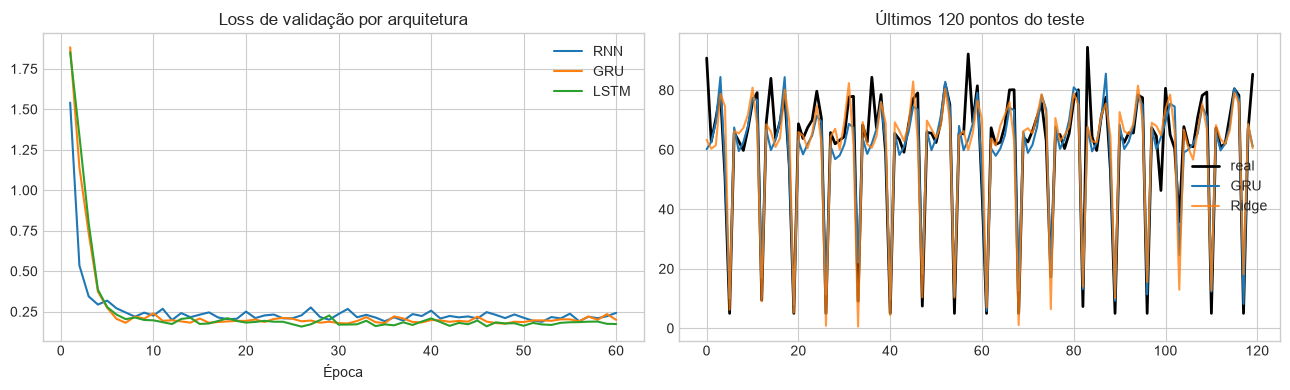

In [6]:
ridge_baseline.fit(X_train.reshape(len(X_train), -1), y_train)
ridge_pred = ridge_baseline.predict(X_test.reshape(len(X_test), -1))
persist_pred = last_value_baseline

results = [
    {'modelo': 'Persistência', **summarize_forecast(y_test, persist_pred), 'parametros': 0},
    {'modelo': 'Naive sazonal', **summarize_forecast(y_test, seasonal_baseline), 'parametros': 0},
    {'modelo': 'Ridge autoregressivo', **summarize_forecast(y_test, ridge_pred),
     'parametros': X_train.reshape(len(X_train), -1).shape[1] + 1},
]
histories = {}
recurrent_predictions = {}

for cell_type in ['rnn', 'gru', 'lstm']:
    torch.manual_seed(SEED)
    model = RecurrentForecaster(cell=cell_type).to(device)
    history_df, criterion = train_recurrent(model, train_loader, val_loader, epochs=60, lr=3e-3)
    metrics = evaluate_recurrent(model, test_loader, criterion)
    recurrent_predictions[cell_type] = metrics['y_pred']
    histories[cell_type] = history_df
    results.append({'modelo': cell_type.upper(), **summarize_forecast(metrics['y_true'], metrics['y_pred']),
                    'parametros': parameter_count(model)})

results_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
print(results_df.round(4).to_string(index=False))
print(f"\nmelhor recorrente: MASE {results_df['MASE'].min():.3f} | "
      f"Ridge: MASE {float(results_df.loc[results_df['modelo'] == 'Ridge autoregressivo', 'MASE'].iloc[0]):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for cell_type, history_df in histories.items():
    axes[0].plot(history_df['epoch'], history_df['val_loss'], label=cell_type.upper())
axes[0].set_title('Loss de validação por arquitetura')
axes[0].set_xlabel('Época')
axes[0].legend()

tail = 120
axes[1].plot(y_test[-tail:], label='real', linewidth=2, color='black')
axes[1].plot(recurrent_predictions['gru'][-tail:], label='GRU')
axes[1].plot(ridge_pred[-tail:], label='Ridge', alpha=0.8)
axes[1].set_title('Últimos 120 pontos do teste')
axes[1].legend()
plt.tight_layout()

## Análise de erro, limitações e próximo experimento
Erros médios mais baixos são importantes, mas o diagnóstico principal aqui é saber **onde** eles acontecem. Como conhecemos o gerador, podemos cortar o erro por regime: dias de promoção contra dias normais, e dias de campanha ativa contra dias fora de campanha. Se a vantagem das células com gates estiver concentrada justamente nos regimes que exigem acumulado, isso é evidência direta de que a memória está sendo usada — e não apenas de que o modelo tem mais parâmetros.

O próximo experimento natural é forecasting multi-horizonte e inclusão explícita de covariáveis futuras conhecidas (calendário promocional planejado).

In [7]:
analysis_df = pd.DataFrame({
    'y_true': y_test,
    'promo': promo_test,
    'campanha': campaign_test,
    'persist': persist_pred,
    'ridge': ridge_pred,
    'rnn': recurrent_predictions['rnn'],
    'gru': recurrent_predictions['gru'],
    'lstm': recurrent_predictions['lstm'],
})

model_cols = ['persist', 'ridge', 'rnn', 'gru', 'lstm']
print(f"dias de teste: {len(analysis_df)} | com promoção: {int(analysis_df['promo'].sum())} "
      f"| em campanha: {int(analysis_df['campanha'].sum())}")

promo_mae = pd.DataFrame([
    {
        'modelo': name,
        'MAE_sem_promocao': mean_absolute_error(
            analysis_df.loc[analysis_df['promo'] == 0, 'y_true'], analysis_df.loc[analysis_df['promo'] == 0, name]),
        'MAE_com_promocao': mean_absolute_error(
            analysis_df.loc[analysis_df['promo'] == 1, 'y_true'], analysis_df.loc[analysis_df['promo'] == 1, name]),
        'MAE_fora_campanha': mean_absolute_error(
            analysis_df.loc[analysis_df['campanha'] == 0, 'y_true'], analysis_df.loc[analysis_df['campanha'] == 0, name]),
        'MAE_em_campanha': mean_absolute_error(
            analysis_df.loc[analysis_df['campanha'] == 1, 'y_true'], analysis_df.loc[analysis_df['campanha'] == 1, name]),
    }
    for name in model_cols
])
print(promo_mae.round(3).to_string(index=False))

worst_days = analysis_df.assign(abs_err_gru=lambda df: np.abs(df['y_true'] - df['gru']),
                                abs_err_ridge=lambda df: np.abs(df['y_true'] - df['ridge']))
print('\n10 piores dias da GRU (com o erro do Ridge no mesmo dia):')
print(worst_days.nlargest(10, 'abs_err_gru')[['y_true', 'gru', 'ridge', 'promo', 'campanha',
                                              'abs_err_gru', 'abs_err_ridge']].round(2).to_string())
worst_days.nlargest(10, 'abs_err_gru')[['y_true', 'gru', 'ridge', 'promo', 'campanha', 'abs_err_gru', 'abs_err_ridge']]

dias de teste: 270 | com promoção: 22 | em campanha: 264
 modelo  MAE_sem_promocao  MAE_com_promocao  MAE_fora_campanha  MAE_em_campanha
persist            24.162            27.479             18.363           24.570
  ridge             4.723            15.525             12.765            5.440
    rnn             4.311            16.382              9.662            5.196
    gru             3.672            13.696             12.526            4.306
   lstm             3.599            13.673             11.651            4.256

10 piores dias da GRU (com o erro do Ridge no mesmo dia):
        y_true        gru      ridge  promo  campanha  abs_err_gru  abs_err_ridge
150  90.760002  60.169998  63.290001    1.0       1.0    30.600000      27.469999
10   96.129997  66.599998  64.019997    1.0       1.0    29.530001      32.110001
207  92.139999  63.349998  59.880001    1.0       1.0    28.790001      32.270000
60   92.580002  64.900002  66.519997    1.0       1.0    27.680000      26.0

,y_true,gru,ridge,promo,campanha,abs_err_gru,abs_err_ridge
150,90.762848,60.166389,63.293812,1.0,1.0,30.596458,27.469036
10,96.131416,66.598938,64.017662,1.0,1.0,29.532478,32.113754
207,92.143028,63.350067,59.876591,1.0,1.0,28.792961,32.266438
60,92.581314,64.898071,66.519608,1.0,1.0,27.683243,26.061707
233,94.398521,67.518272,67.606606,1.0,1.0,26.880249,26.791916
269,85.351784,61.084705,60.500313,1.0,1.0,24.267078,24.851471
164,83.959579,59.852844,66.029419,1.0,1.0,24.106735,17.930161
103,91.356781,67.288727,66.566803,1.0,1.0,24.068054,24.789978
186,84.324371,62.125759,60.619217,1.0,1.0,22.198612,23.705154
14,7.616489,27.280167,43.323540,0.0,1.0,19.663677,35.707050


## Fechamento e próximos passos
O resultado sustenta a hipótese. Na execução de referência (semente 42):

| modelo | MAE | MASE | leitura |
|---|---|---|---|
| LSTM | 4.42 | **0.672** | melhor que o naive sazonal e melhor que o Ridge |
| GRU | 4.49 | **0.682** | praticamente empatada com a LSTM |
| RNN vanilla | 5.29 | 0.805 | aprende, mas fica atrás das células com gates |
| Ridge autoregressivo | 5.60 | 0.851 | baseline forte e honesto, mas linear |
| Naive sazonal | 6.53 | 0.991 | referência do MASE |
| Persistência | 24.43 | 3.712 | inviável com sazonalidade semanal forte |

**GRU e LSTM ficam abaixo de MASE 1 e abaixo do Ridge** (cerca de 21% menos erro absoluto), enquanto a RNN vanilla fica no meio do caminho. O Ridge continua sendo um baseline forte — ele não é um espantalho, e em muitos problemas reais ele ganha —, mas aqui ele bate no teto do que uma função linear das defasagens consegue representar. A vantagem das células com gates aparece exatamente onde a teoria previa: nos dias de promoção (MAE 13.7 da LSTM contra 15.5 do Ridge) e nos dias de campanha ativa (4.26 contra 5.44), isto é, nos regimes que dependem de um acumulado latente.

A lição de método é tão importante quanto o número: a versão anterior deste notebook gerava a série com `demanda[t] = 20 + 0.5·lag1 + 0.15·lag7 + ...`, ou seja, um processo **linear**. Naquele desenho, o Ridge era o estimador ótimo por construção e a LSTM não tinha o que aprender — o experimento não media arquitetura, media o gerador. Antes de concluir que "modelo X não serve para o problema Y", vale sempre perguntar se o dataset tem o sinal que a arquitetura foi feita para capturar.

A próxima aula transfere essa discussão de memória temporal para dependências globais entre tokens, mostrando como atenção e Transformers substituem o gargalo recorrente por mecanismos relacionais mais flexíveis.